##DATA CLEANING

In [ ]:
##IMPORTING LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

In [ ]:
df = pd.read_csv("../data/raw/superstore.csv", encoding="cp1252")

print("Data loaded successfully!")

In [ ]:
##CHECKING FOR NULL VALUES
df.isnull().sum()

In [ ]:
##CHECKING FOR DUPLICATES
df.duplicated().sum()

In [6]:
##CONVERTING DATE COLUMNS TO DATETIME FORMAT
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [ ]:
##SELECTING NUMERIC COLUMNS
numeric_columns = ["Sales", "Quantity", "Discount", "Profit"]

df[numeric_columns].head()

In [ ]:
##CHECKING DATA TYPES OF NUMERIC COLUMNS
df[numeric_columns].dtypes

In [ ]:
##DESCRIPTIVE STATISTICS OF NUMERIC COLUMNS
df[numeric_columns].describe()

In [ ]:
##CHECKING IF THE VALUES MAKE BUSINESS SENSE
#SALES HAVE TO BE POSITIVE
(df["Sales"] <= 0).sum()

In [ ]:
##QUANTITY HAS TO BE POSITIVE
(df["Quantity"] <= 0).sum()

In [ ]:
##DISCOUNT HAS TO BE BETWEEN 0 AND 1
print("Discount below 0:", (df["Discount"] < 0).sum())
print("Discount above 1:", (df["Discount"] > 1).sum())

In [ ]:
##PROFIT CAN BE POSITIVE-PROFIT OR NEGATIVE-LOSS
##CHECKING HOW MANY LOSS TRANSACTIONS ARE THERE
(df["Profit"] < 0).sum()

In [ ]:
##CHECKING HOW MANY POSITIVE PROFIT TRANSACTIONS ARE THERE
(df["Profit"] > 0).sum()

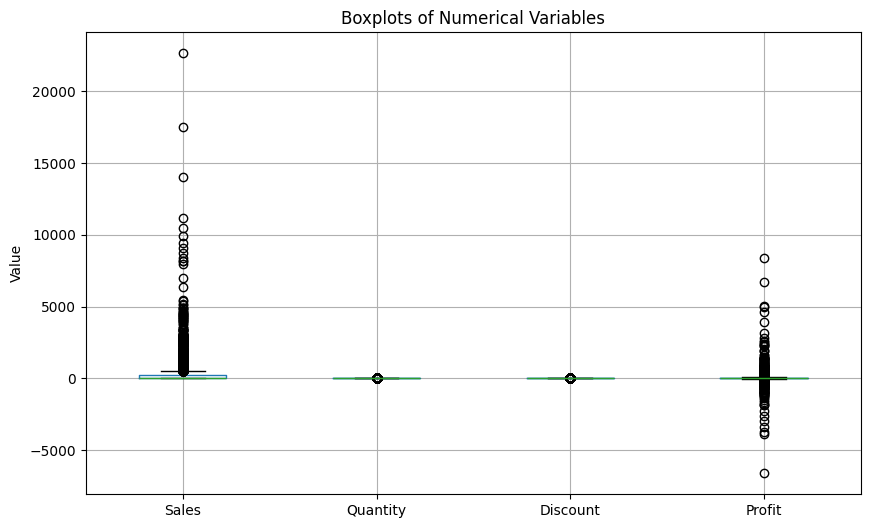

In [15]:
##CHECKING FOR EXTREME VALUES IN NUMERIC COLUMNS
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df[numeric_columns].boxplot()

plt.title("Boxplots of Numerical Variables")
plt.ylabel("Value")

plt.show()

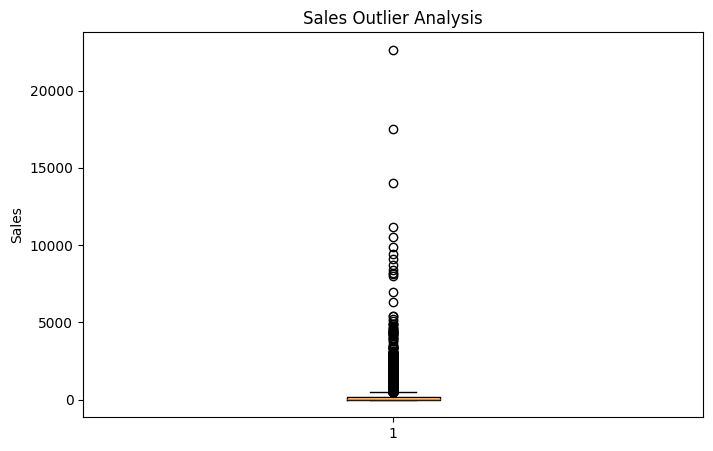

In [30]:
##BOXPLOT FOR SALES
plt.figure(figsize=(8, 5))
plt.boxplot(df["Sales"].dropna())

plt.title("Sales Outlier Analysis")
plt.ylabel("Sales")

plt.show()

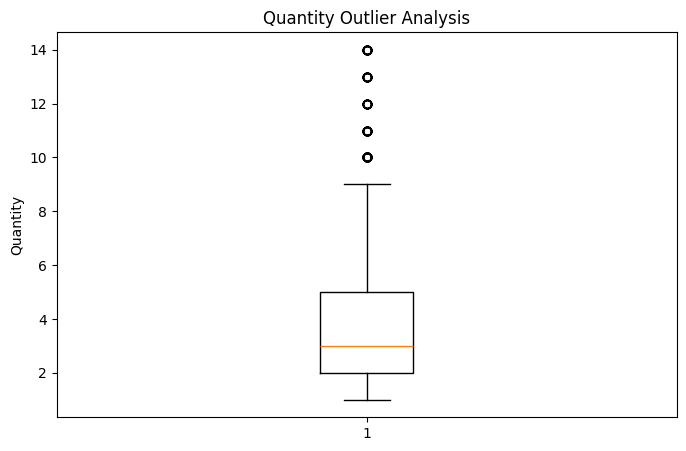

In [31]:
##BOXPLOT FOR QUANTITY
plt.figure(figsize=(8, 5))
plt.boxplot(df["Quantity"].dropna())

plt.title("Quantity Outlier Analysis")
plt.ylabel("Quantity")

plt.show()

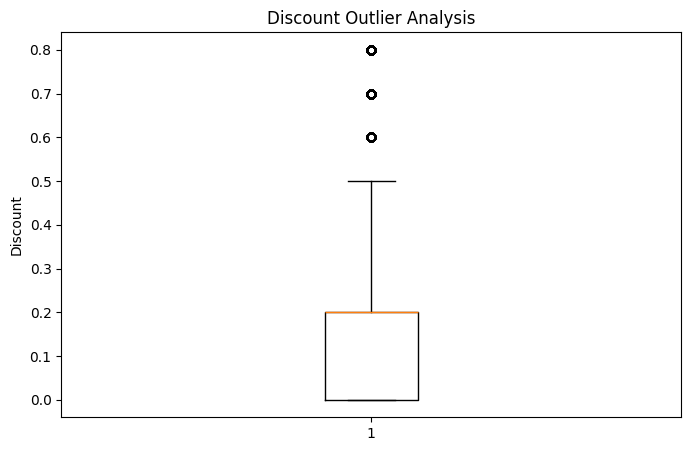

In [32]:
##BOXPLOT FOR DISCOUNT
plt.figure(figsize=(8, 5))
plt.boxplot(df["Discount"].dropna())

plt.title("Discount Outlier Analysis")
plt.ylabel("Discount")

plt.show()

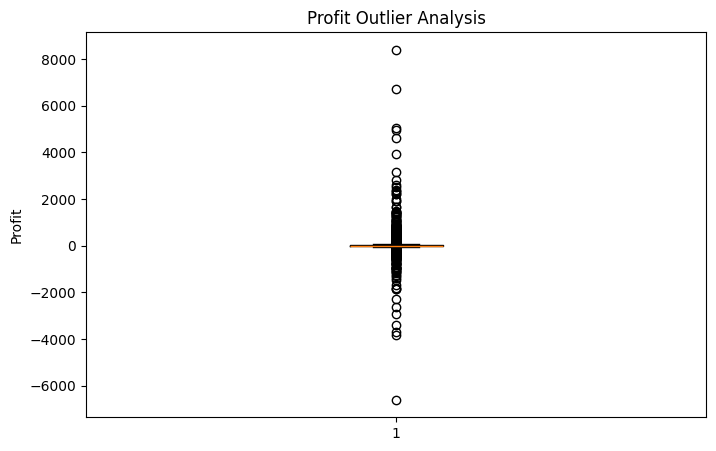

In [33]:
##BOXPLOT FOR PROFIT
plt.figure(figsize=(8, 5))
plt.boxplot(df["Profit"].dropna())

plt.title("Profit Outlier Analysis")
plt.ylabel("Profit")

plt.show()

## Numerical Variable Quality Assessment

The numerical variables examined in the dataset are Sales, Quantity, Discount and Profit.

The variables were assessed for their data types, missing values, statistical distributions, invalid values and potential outliers.

Sales was examined to identify zero or negative values and unusually large transactions. Quantity was assessed to ensure that transaction quantities were valid positive values. Discount was checked to ensure that values were within the expected range of 0 to 1. Profit was examined for negative values, which represent loss-making transactions, and these values were retained because negative profit is a valid business outcome.

Boxplots and distribution plots were used to identify potential outliers and understand the distribution of each numerical variable.

In [17]:
##INVESTIGATING OUTLIERS USING IQR
##CREATING A FUNCTION TO IDENTIFY OUTLIERS BASED ON IQR METHOD

def investigate_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print(f"\n===== {column} =====")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of potential outliers: {len(outliers)}")
    print(f"Percentage of observations: {(len(outliers) / len(data)) * 100:.2f}%")

    return outliers

In [ ]:
##INVESTIGATING OUTLIERS FOR SALES
sales_outliers = investigate_outliers(df, "Sales")

In [ ]:
##INVESTIGATING OUTLIERS FOR QUANTITY
quantity_outliers = investigate_outliers(df, "Quantity")

In [ ]:
##INVESTIGATING OUTLIERS FOR DISCOUNT
discount_outliers = investigate_outliers(df, "Discount")

In [ ]:
##INVESTIGATING OUTLIERS FOR PROFIT
profit_outliers = investigate_outliers(df, "Profit")

In [ ]:
##LOOKING INTO THE ACTUAL OUTLIERS FOR SALES
sales_outliers.sort_values(
    by="Sales",
    ascending=False
).head(10)

In [ ]:
##LOOKING INTO THE ACTUAL OUTLIERS FOR QUANTITY
quantity_outliers.sort_values(
    by="Quantity",
    ascending=False
).head(10)

In [ ]:
##LOOKING INTO THE ACTUAL OUTLIERS FOR DISCOUNT
discount_outliers.sort_values(
    by="Discount",
    ascending=False
).head(10)

In [ ]:
##LOOKING INTO THE ACTUAL OUTLIERS FOR POSITIVE PROFIT
profit_outliers.sort_values(
    by="Profit",
    ascending=False
).head(10)

In [ ]:
##LOOKING INTO OUTLIERS FOR NEGATIVE PROFIT
profit_outliers.sort_values(
    by="Profit",
    ascending=True
).head(10)

In [ ]:
##OUTLIER SUMMARY TABLE
outlier_summary = []

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Variable": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": (len(outliers) / len(df)) * 100
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

In [28]:
## MAKING A COPY OF THE DATAFRAME FOR CLEANING PURPOSES
df_clean = df.copy()

In [ ]:
##CHECKING CATEGORICAL VALUES
categorical_columns = [
    "Ship Mode",
    "Segment",
    "Country",
    "City",
    "State",
    "Region",
    "Category",
    "Sub-Category",
    "Product Name"
]

print(categorical_columns)

In [ ]:
##CHECKING DATA TYPES OF CATEGORICAL COLUMNS
df_clean[categorical_columns].dtypes

In [ ]:
##CHECKING UNIQUE VALUES IN CATEGORICAL COLUMNS
df_clean[categorical_columns].nunique()

In [ ]:
##CHECKING THE ACTUAL CATEGORIES
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print("Number of unique values:", df_clean[column].nunique())
    print("Values:", df_clean[column].unique())

In [ ]:
##CHECKING FREQUENCY OF CATEGORIES IN CATEGORICAL COLUMNS
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df_clean[column].value_counts())

In [ ]:
##CHECKING FOR SPACES /INCOSISTENT FORMATTING IN CATEGORICAL COLUMNS
for column in categorical_columns:
    spaces = df_clean[column].astype(str).str.strip() != df_clean[column].astype(str)
    print(f"{column}: {spaces.sum()} values with extra spaces")

In [35]:
##REMOVING UNNECESSARY SPACES FROM CATEGORICAL COLUMNS
for column in categorical_columns:
    df_clean[column] = df_clean[column].str.strip()

In [ ]:
##CHECKING FOR CAPITALIZATION
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df_clean[column].unique())

In [ ]:
##CHECKING FOR BLANK SPACES
for column in categorical_columns:
    blank_count = (df_clean[column].str.strip() == "").sum()
    print(f"{column}: {blank_count} blank values")

In [ ]:
print(df_clean.columns.tolist())

In [ ]:
print(df_clean.shape)

In [ ]:
df_clean.info()